# 05 Total Behandlingstid (Produktmodell)

Formaal:
- Predikere `total_behandlingstid` som produkt av to delmodeller:
  - `antall_samtaler` (Poisson)
  - `behandlingstid_snitt` (Ridge)
- Evaluere out-of-fold mot relevante baselines
- Se diagnostikk for hvor modellen feiler

In [9]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

project_root = Path.cwd().resolve().parent.parent
code_dir = project_root / "code"
if str(code_dir) not in sys.path:
    sys.path.append(str(code_dir))

from utils.data_load import load_raw_data
from utils.data_prep import data_prep
from utils.models import (
    build_count_model,
    build_mean_duration_model,
    DEFAULT_CATEGORICAL_FEATURES,
)

In [10]:
# Konfig
COUNT_TARGET = "antall_samtaler"
DURATION_TARGET = "behandlingstid_snitt"
TOTAL_TARGET = "total_behandlingstid"
WEIGHT_COL = "antall_samtaler"

K_FOLDS = 10
RANDOM_STATE = 42
POISSON_ALPHA = 0.3
POISSON_MAX_ITER = 10000

NEWSLETTER_CSV = project_root / "data" / "newsletter_sendouts.csv"
WEATHER_CSV = project_root / "data" / "oslo_weather.csv"

count_feature_cols = [
    "maaned",
    "stddev_premieendring_b30_for",
    "antall_nye_kunder_b30_tot",
    "tempavvik_fra_mndsnitt",
    "er_dag_foer_helligdag",
    "ukedag",
    "snitt_premieendring_b30_for"
]

duration_feature_cols = [
    "antall_nye_kunder_b30_tot",
    "maaned",
    "stddev_premieendring_b30_for",
    "snitt_premieendring_b30_for"
]

In [11]:
# Last data og bygg analyseklar dataframe
df_inngang, df_info, df_weather = load_raw_data(
    session=None,
    weather_path=WEATHER_CSV,
)

df = data_prep(
    df_inngang=df_inngang,
    df_info=df_info,
    df_weather=df_weather,
    cols_to_remove=None,
    newsletter_dates_csv=str(NEWSLETTER_CSV),
)

print("Prepared shape:", df.shape)
print("Dato fra/til:", df["ankomst_dato"].min(), "->", df["ankomst_dato"].max())

Prepared shape: (499, 132)
Dato fra/til: 2024-06-03 -> 2026-06-02


In [12]:
# Klargjor feature-sett og evalueringsdata
count_missing = [c for c in count_feature_cols if c not in df.columns]
duration_missing = [c for c in duration_feature_cols if c not in df.columns]

count_feature_cols = [c for c in count_feature_cols if c in df.columns]
duration_feature_cols = [c for c in duration_feature_cols if c in df.columns]

if count_missing:
    print("Count-features som mangler og hoppes over:", count_missing)
if duration_missing:
    print("Duration-features som mangler og hoppes over:", duration_missing)

if len(count_feature_cols) == 0 or len(duration_feature_cols) == 0:
    raise ValueError("Feature-sett er tomt etter validering.")

required_cols = sorted(set(count_feature_cols + duration_feature_cols + [
    COUNT_TARGET,
    DURATION_TARGET,
    TOTAL_TARGET,
    WEIGHT_COL,
    "ankomst_dato",
]))

frame = df[required_cols].dropna().copy()
frame[WEIGHT_COL] = frame[WEIGHT_COL].astype(float)

if (frame[WEIGHT_COL] < 0).any():
    raise ValueError("Vektkolonnen inneholder negative verdier.")

print("Eval shape:", frame.shape)
print("Count features:", count_feature_cols)
print("Duration features:", duration_feature_cols)

Eval shape: (455, 11)
Count features: ['maaned', 'stddev_premieendring_b30_for', 'antall_nye_kunder_b30_tot', 'tempavvik_fra_mndsnitt', 'er_dag_foer_helligdag', 'ukedag', 'snitt_premieendring_b30_for']
Duration features: ['antall_nye_kunder_b30_tot', 'maaned', 'stddev_premieendring_b30_for', 'snitt_premieendring_b30_for']


In [13]:
# OOF-evaluering: produktmodell vs baselines

def _metric_row(y_true, y_pred, sample_weight=None):
    return {
        "mae": mean_absolute_error(y_true, y_pred, sample_weight=sample_weight),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred, sample_weight=sample_weight))),
        "r2": r2_score(y_true, y_pred, sample_weight=sample_weight),
    }

cv = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_results = []

oof_rows = []

X_count_all = frame[count_feature_cols]
X_duration_all = frame[duration_feature_cols]
y_count_all = frame[COUNT_TARGET].astype(float)
y_duration_all = frame[DURATION_TARGET].astype(float)
y_total_all = frame[TOTAL_TARGET].astype(float)
w_all = frame[WEIGHT_COL].astype(float)

for fold_id, (train_idx, test_idx) in enumerate(cv.split(frame), start=1):
    Xc_train = X_count_all.iloc[train_idx]
    Xc_test = X_count_all.iloc[test_idx]

    Xd_train = X_duration_all.iloc[train_idx]
    Xd_test = X_duration_all.iloc[test_idx]

    y_count_train = y_count_all.iloc[train_idx]
    y_duration_train = y_duration_all.iloc[train_idx]
    y_total_test = y_total_all.iloc[test_idx]

    w_train = w_all.iloc[train_idx].to_numpy()
    w_test = w_all.iloc[test_idx].to_numpy()

    cat_count = [c for c in DEFAULT_CATEGORICAL_FEATURES if c in count_feature_cols]
    cat_duration = [c for c in DEFAULT_CATEGORICAL_FEATURES if c in duration_feature_cols]

    count_model = build_count_model(
        Xc_train,
        categorical_features=cat_count,
        alpha=POISSON_ALPHA,
        max_iter=POISSON_MAX_ITER,
    )
    count_model.fit(Xc_train, y_count_train)

    duration_model = build_mean_duration_model(
        Xd_train,
        categorical_features=cat_duration,
        alpha=1.0,
    )
    duration_model.fit(Xd_train, y_duration_train, model__sample_weight=w_train)

    pred_count = np.clip(count_model.predict(Xc_test), 1e-9, None)
    pred_duration = np.clip(duration_model.predict(Xd_test), 1e-9, None)
    pred_total_product = pred_count * pred_duration

    baseline_total = np.full(len(test_idx), float(y_total_all.iloc[train_idx].mean()))

    baseline_count = float(y_count_train.mean())
    baseline_duration = float(np.average(y_duration_train, weights=w_train))
    baseline_product = np.full(len(test_idx), baseline_count * baseline_duration)

    for model_name, pred in [
        ("product_model", pred_total_product),
        ("baseline_total_mean", baseline_total),
        ("baseline_decomposed", baseline_product),
    ]:
        m_unweighted = _metric_row(y_total_test, pred)
        m_weighted = _metric_row(y_total_test, pred, sample_weight=w_test)
        fold_results.append(
            {
                "fold": fold_id,
                "model": model_name,
                "mae": m_unweighted["mae"],
                "rmse": m_unweighted["rmse"],
                "r2": m_unweighted["r2"],
                "mae_w": m_weighted["mae"],
                "rmse_w": m_weighted["rmse"],
                "r2_w": m_weighted["r2"],
            }
        )

    fold_oof = frame.iloc[test_idx][["ankomst_dato", TOTAL_TARGET, WEIGHT_COL]].copy()
    fold_oof["pred_total_product"] = pred_total_product
    fold_oof["pred_baseline_total_mean"] = baseline_total
    fold_oof["pred_baseline_decomposed"] = baseline_product
    oof_rows.append(fold_oof)

fold_df = pd.DataFrame(fold_results)
fold_df.head()

,fold,model,mae,rmse,r2,mae_w,rmse_w,r2_w
0,1,product_model,20376.178267,27288.989271,0.230985,19001.405547,25184.734667,0.224547
1,1,baseline_total_mean,25499.578877,31270.539223,-0.009789,23857.008258,29614.097122,-0.072205
2,1,baseline_decomposed,25499.578877,31270.539223,-0.009789,23857.008258,29614.097122,-0.072205
3,2,product_model,16488.570306,22674.302222,0.423033,15101.795534,20045.548209,0.424775
4,2,baseline_total_mean,25320.604125,30408.112716,-0.037677,22109.203705,26684.422053,-0.019336


In [14]:
# Oppsummering av metrikker
agg = (
    fold_df.groupby("model", as_index=False)
    .agg(
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        mae_w_mean=("mae_w", "mean"),
        mae_w_std=("mae_w", "std"),
        rmse_w_mean=("rmse_w", "mean"),
        rmse_w_std=("rmse_w", "std"),
        r2_w_mean=("r2_w", "mean"),
        r2_w_std=("r2_w", "std"),
    )
    .sort_values("rmse_w_mean")
)

agg

,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,mae_w_mean,mae_w_std,rmse_w_mean,rmse_w_std,r2_w_mean,r2_w_std
2,product_model,18077.670173,2138.088683,23657.962452,2860.622809,0.330964,0.119311,17778.496573,2193.178861,23107.971212,2929.241253,0.219493,0.141907
0,baseline_decomposed,23494.300534,2048.272383,29464.975180,1947.974799,-0.032094,0.032681,22274.538957,1638.685583,28051.815149,2212.841014,-0.147190,0.120402
1,baseline_total_mean,23494.300534,2048.272383,29464.975180,1947.974799,-0.032094,0.032681,22274.538957,1638.685583,28051.815149,2212.841014,-0.147190,0.120402


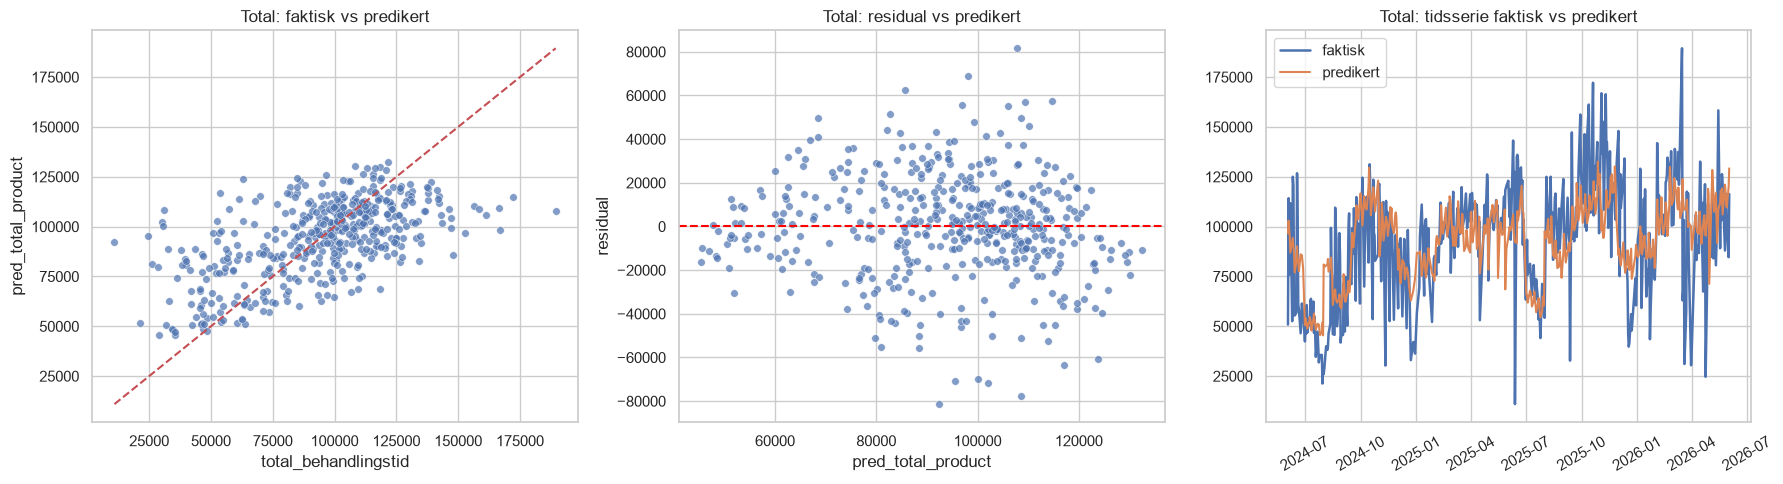

In [15]:
# Diagnostikk for produktmodellen
oof_df = pd.concat(oof_rows, ignore_index=True).sort_values("ankomst_dato").reset_index(drop=True)

y_true = oof_df[TOTAL_TARGET]
y_pred = oof_df["pred_total_product"]
residual = y_true - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_true, y=y_pred, s=30, alpha=0.7, ax=axes[0])
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--")
axes[0].set_title("Total: faktisk vs predikert")
axes[0].set_xlabel(TOTAL_TARGET)
axes[0].set_ylabel("pred_total_product")

sns.scatterplot(x=y_pred, y=residual, s=30, alpha=0.7, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Total: residual vs predikert")
axes[1].set_xlabel("pred_total_product")
axes[1].set_ylabel("residual")

axes[2].plot(oof_df["ankomst_dato"], y_true, label="faktisk", linewidth=1.8)
axes[2].plot(oof_df["ankomst_dato"], y_pred, label="predikert", linewidth=1.5)
axes[2].set_title("Total: tidsserie faktisk vs predikert")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend()

plt.tight_layout()
plt.show()

In [16]:
# Toppfeil og enkel dekomponering
oof_df["abs_error_product"] = (oof_df[TOTAL_TARGET] - oof_df["pred_total_product"]).abs()
oof_df["abs_error_baseline"] = (oof_df[TOTAL_TARGET] - oof_df["pred_baseline_total_mean"]).abs()

top_errors = oof_df.nlargest(10, "abs_error_product")[[
    "ankomst_dato",
    TOTAL_TARGET,
    WEIGHT_COL,
    "pred_total_product",
    "pred_baseline_total_mean",
    "pred_baseline_decomposed",
    "abs_error_product",
    "abs_error_baseline",
]]

top_errors

,ankomst_dato,total_behandlingstid,antall_samtaler,pred_total_product,pred_baseline_total_mean,pred_baseline_decomposed,abs_error_product,abs_error_baseline
407,2026-03-16,189454,591.0,107822.860599,93571.529268,93571.529268,81631.139401,95882.470732
223,2025-06-13,10966,34.0,92322.839982,93759.270732,93759.270732,81356.839982,82793.270732
411,2026-03-20,31056,101.0,108482.964722,94314.185819,94314.185819,77426.964722,63258.185819
102,2024-11-11,30303,162.0,102083.108753,93809.460976,93809.460976,71780.108753,63506.460976
431,2026-04-24,24659,81.0,95472.554139,94588.701711,94588.701711,70813.554139,69929.701711
417,2026-03-31,30437,87.0,100117.481961,93572.763415,93572.763415,69680.481961,63135.763415
318,2025-11-03,166881,529.0,98138.998742,93178.374083,93178.374083,68742.001258,73702.625917
90,2024-10-21,53576,173.0,117070.493787,94314.185819,94314.185819,63494.493787,40738.185819
338,2025-12-01,147982,482.0,85655.590900,94765.129268,94765.129268,62326.409100,53216.870732
408,2026-03-17,62961,238.0,123802.960674,94765.129268,94765.129268,60841.960674,31804.129268


## Notater

- Produktmodell evalueres out-of-fold for aa unngaa leakage.
- `duration_model` trenes vektet med `antall_samtaler`.
- Oppsummeringstabellen viser baade uvektede og vektede metrikker.